Qubit pair is not valid on device: (cirq.GridQubit(5, 6), cirq.GridQubit(4, 5)).
Simulate the bell state circuit:
measurements: (no measurements)

qubits: (cirq.LineQubit(0), cirq.LineQubit(1))
output vector: 0.707|00⟩ + 0.707|11⟩

phase:
output vector: |⟩
Sample the bell state circuit:
result=101100111000000000010000100110100101101001001001110000100101011110000110000110101100110000010010110110010001011111001010101100100011111100111001000100011011111001111100110110111000110000110110000000010100011100101110101001110100100101011011000011101100110111010000000001000110100100010010000100110110001010011010100000101000110101100101010111101011000000100100101101000110100001101000011110011011101011111000111011110111100111000101110000100000011000001101010000001101111000000011110111001101010111100000101001001011011111111101010110010000000100000111101000010100110001000110111010101001110011110011011111111100101001001000110000101110011001011101101011010110101000101010011010111111110110100110001010010

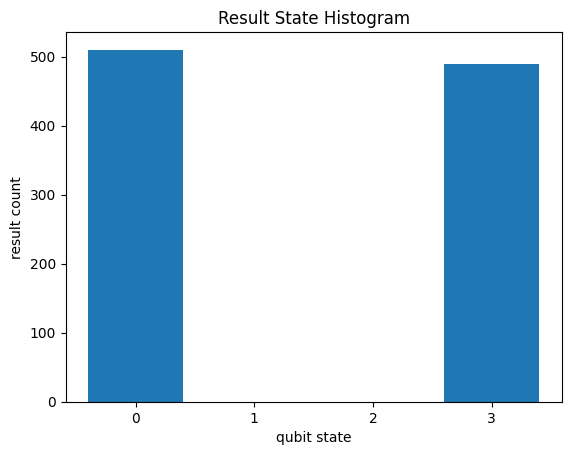

Counter({0: 510, 3: 490})


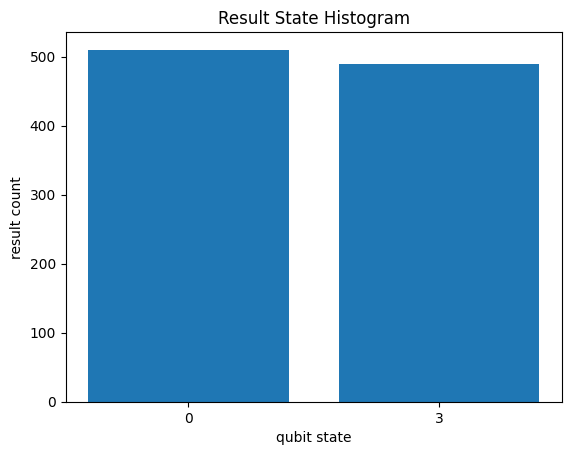

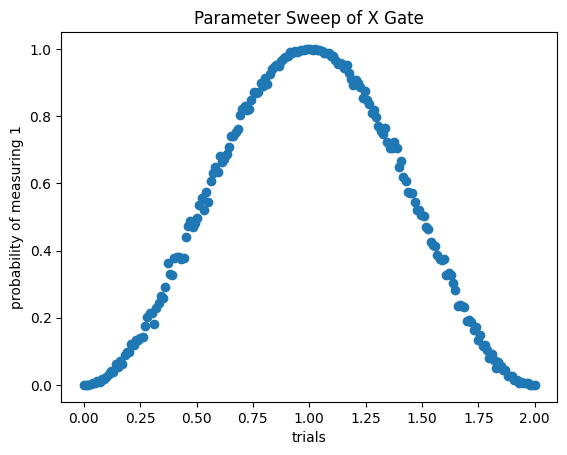

Unitary matrix for the X gate:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Unitary of SWAP operator on two qubits.
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
Unitary of a sample circuit
[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]
[(cirq.Y**0.5).on(cirq.LineQubit(0)), cirq.XPowGate(global_shift=-0.25).on(cirq.LineQubit(0))]
[(cirq.Y**0.5).on(cirq.LineQubit(2)), cirq.XPowGate(global_shift=-0.25).on(cirq.LineQubit(2)), cirq.T(cirq.LineQubit(0)), cirq.T(cirq.LineQubit(1)), cirq.T(cirq.LineQubit(2)), (cirq.Y**-0.5).on(cirq.LineQubit(1)), cirq.CZ(cirq.LineQubit(0), cirq.LineQubit(1)), (cirq.Y**0.5).on(cirq.LineQubit(1)), (cirq.Y**-0.5).on(cirq.LineQubit(2)), cirq.CZ(cirq.LineQubit(1), cirq.LineQubit(2)), (cirq.Y**0.5).on(cirq.LineQubit(2)), (cirq.T**-1).on(cirq.LineQubit(1)), cirq.T(cirq.LineQubit(2)), (cirq.Y**-0.5).on(cirq.LineQubit(1)), 

In [ ]:
from asyncio import run

import cirq
import cirq_google
import matplotlib.pyplot as plt
import sympy 

# ways to define a qubit

cirq.NamedQubit("a")  # labels quibit with a string
cirq.LineQubit(0) # labels qubits in a line with integers
cirq.GridQubit(0, 0)  # labels qubits in a grid

q0 = cirq.NamedQubit('source')
q1 = cirq.NamedQubit('target')
#named qubits are good for abstract algorithms.

q3=cirq.LineQubit(3)
#line qubits can be made individually

q0, q1, q3 = cirq.LineQubit.range(3)
#or in a range

q4_5 = cirq.GridQubit(4, 5)
#grid qubits are good for representing physical layouts of qubits. they can also be referenced individually

#or they can be made in a grid
qubits = cirq.GridQubit.square(4) 

#pre-packaged sets of qubits are called devices
# print(cirq_google.Sycamore) <-- prints a 54 qubit grid that google released early 

#GATES AND OPERATIONS 

#a gates is an effect that can be applied to a qubit. 
#an operation is a gate applied to specific qubits at a specific time.

#examples of gates
cirq.X  # the NOT gate, also called the Pauli X gate
cirq.Y  # the Pauli Y gate
cirq.Z  # the Pauli Z gate
cirq.H  # the Hadamard gate
cirq.CNOT  # the controlled NOT gate, also called the CX gate

#exponentation for square root gates
sqrt_x_gate = cirq.X**0.5 # the square root of X gate

#some gates take parameters
sqrt_sqrt_y_gate = cirq.YPowGate(exponent=0.25) # the fourth root of Y gate

q0, q1 = cirq.LineQubit.range(2)
#creates two qubits in a line

#examples of operations
cirq.X(q0)  # applies the X gate to qubit q0
cirq.CNOT(q0, q1)  # applies the CNOT gate with control
cirq.SQRT_ISWAP(q0, q1)  # applies the square root of iSWAP gate to qubits q0 and q1

##CIRCUITS

#circuits are collections of moments which are collections of operations
# a moment is basically a vertical slice of da circuit, where all operations in a moment are applied simultaneously

#append can be used to add operations to a circuit
circuit = cirq.Circuit()
q0, q1, q2 = cirq.LineQubit.range(3)
circuit.append(cirq.H(q0))  # applies the H gate to qubit q0
circuit.append(cirq.H(q1))  # applies the H gate to qubit q1
circuit.append(cirq.H(q2))

#or you can add multiple operations at once

circuit1 = cirq.Circuit()
ops = [cirq.H(q) for q in cirq.LineQubit.range(3)]
circuit1.append(ops)

#appending with generators is also possible
circuit2 = cirq.Circuit()
circuit2.append(cirq.H(q) for q in cirq.LineQubit.range(3))

#initialization of a circuit with operations is also possible
# print(cirq.Circuit(cirq.H(q) for q in cirq.LineQubit.range(3)))

#print(cirq.Circuit(cirq.Moment([cirq.H(q)]) for q in cirq.LineQubit.range(3)))

# this creates a circuit with three moments, each containing one H gate on a different qubit.

#Devices are good for understanding the constraints of quantum hardware. 

#defined qubits'
q5 = cirq.GridQubit(5, 6)
q6 = cirq.GridQubit(5, 5)
q7 = cirq.GridQubit(4, 5)

#The Sycamore device can only apply two-qubit gates between qubits that are adjacent on the grid.
#This means that non-adjacent qubits would output an error if we tried to apply a two-qubit gate between them.

adjacent_op = cirq_google.SYC(q5, q6)
nonadjacent_op = cirq_google.SYC(q5, q7)

working_circuit = cirq.Circuit()
working_circuit.append(adjacent_op)
valid = cirq_google.Sycamore.validate_circuit(working_circuit)

#since q5 and q6 are adjacent, this circuit is valid. However, if we try to append the nonadjacent operation, we will get an error.

bad_circuit = cirq.Circuit()
bad_circuit.append(nonadjacent_op)
try:
    cirq_google.Sycamore.validate_circuit(bad_circuit)
except ValueError as e:
    print(e)

#Note: the try and except block is used to catch the ValueError when we validate the bad circuit. Instead of crashing the program, it will print the error message. This isn't the device. cirq_google.Sycamore.validate_circuit() method that checks if the circuit is valid for the Sycamore device.

#SIMULATION 

# cirq.Simulator() #innitializes a simulator object that can be used to run quantum circuits with a limit of 20 qubits.

# simulate() #runs a quantum circuit on the simulator and returns the final state of the qubits after the circuit has been executed.

# run() #runs a quantum circuit on the simulator and returns the measurement results of the qubits after the circuit has been executed.

#Simulating a 2-qubit bell state circuit
# 1/sqrt(2) (|00> + |11>) <-- this is da bell state

bell_circuit = cirq.Circuit()
q0, q1 = cirq.LineQubit.range(2)
bell_circuit.append(cirq.H(q0))  # this puts q0 in superposition
bell_circuit.append(cirq.CNOT(q0, q1))  # this entangles q0 and q1

s = cirq.Simulator()

print('Simulate the bell state circuit:')
results = s.simulate(bell_circuit)
print(results)

#for sampling we gotta measure the results
bell_circuit.append(cirq.measure(q0, q1, key='result'))

#sample the circuit
samples = s.run(bell_circuit, repetitions=1000)
print('Sample the bell state circuit:')
print(samples)

#VISUALIZATION

#when you use run() to sample a circuit, you can get a histogram of the results using cirq.plot_state_histogram().

cirq.plot_state_histogram(samples, plt.subplot())
plt.show()

#this historgram has empty bars for the |01> and |10> states, which is what we expect for a bell state. The |00> and |11> states should have equal heights, which is also what we see in the histogram. however, this may be a problem for working with more qubits, since the number of possible states grows exponentially with the number of qubits.

# Pull of histogram counts from the result data structure
counts = samples.histogram(key='result')
print(counts)

# Graph the histogram counts instead of the results
cirq.plot_state_histogram(counts, plt.subplot())
plt.show()

#A histogram of the states we actually observed can be more useful for analysing results 

#PARAMETER SWEEPS

#parameter sweeps are a way to run a circuit multiple times with different parameter values. This is useful for things like variational algorithms, where you want to find the optimal parameters for a circuit.

#Once a circuit is complete you can fill parameters with a sweep. 

#Makes and X gate with a variable exponent using sympy. Symbol
q = cirq.GridQubit(1, 1)
circuit7 = cirq.Circuit(cirq.X(q)**sympy.Symbol('t'), cirq.measure(q, key='m'))

#Sweep exponent from 0 (off) to 1 (on) in and back to two (off again)
param_sweep = cirq.Linspace('t', start=0, stop=2, length=200)

#Run the sweep
r = cirq.Simulator()
trials = r.run_sweep(circuit7, param_sweep, repetitions=1000)

#Plot the results

x_data = [trial.params['t'] for trial in trials]
y_data = [trial.histogram(key='m')[1]/1000 for trial in trials]
plt.scatter('t','p', data={'t': x_data, 'p': y_data})
plt.xlabel('trials')
plt.ylabel('probability of measuring 1')
plt.title('Parameter Sweep of X Gate')
plt.show()

#Unitary Matrices and Decompositions

#many quantum operations can be represented as unitary matrices. For example, the X gate can be represented as the following matrix:
print('Unitary matrix for the X gate:')
print(cirq.unitary(cirq.X))

print('Unitary of SWAP operator on two qubits.')
q0, q1 = cirq.LineQubit.range(2)
print(cirq.unitary(cirq.SWAP(q0, q1)))

print('Unitary of a sample circuit')
print(cirq.unitary(cirq.Circuit(cirq.X(q0), cirq.SWAP(q0, q1))))

#many gates can be decomposed into simpler gates. For example, the H gate can be decomposed into a sequence of X and Z gates.

print(cirq.decompose(cirq.H(cirq.LineQubit(0))))

#another example is the 3 qubit Toffoli gate. many devices don't support 3 qubit gates, but we can decompose it into a sequence of 2 qubit gates.

q10, q11, q12 = cirq.LineQubit.range(3)
print(cirq.decompose(cirq.TOFFOLI(q10, q11, q12)))

#TRANSFORMERS

w = cirq.GridQubit(1, 1)
c = cirq.Circuit(cirq.X(w)**0.25, cirq.Y(w)**0.25, cirq.Z(w)**0.25)
print(c)
c = cirq.merge_single_qubit_gates_to_phxz(c)
print(c)

#Transformers are used to manipulate circuits. For example, the merge_single_qubit_gates_to_phxz() transformer merges consecutive single-qubit gates into a single gate in the PHXZ basis. This can simplify the circuit and make it more efficient to run on hardware.



